# NeuroSegment-BraTS: Resultados e Explicabilidade

**Notebook 5:** Resultados e Explicabilidade através de XAI



## 1. Configuração e Carga dos Modelos

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload

import os
import gc
import sys
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))

from torch import amp

from src.data_utils import get_val_transforms, get_sample_data
from monai.visualize import GradCAM
from monai.networks.blocks import ResBlock
from monai.networks.nets import SwinUNETR, UNet, SegResNet

# Carregar transformações
transforms = get_val_transforms()

# Preparar uma única amostra para XAI
data_dir = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

patient_id = "BraTS20_Training_001"
sample = get_sample_data(data_dir, patient_id)
processed_sample = transforms(sample)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# O BraTS usa 4 modalidades (FLAIR, T1, T1ce, T2) como canais de entrada
input_tensor = processed_sample["image"].unsqueeze(0).to(device)
input_tensor.requires_grad = True
print(f"Shape para XAI: {input_tensor.shape}")


/home/leovianaf/projetos/NeuroSegment-BraTS-MONAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/leovianaf/projetos/NeuroSegment-BraTS-MONAI/venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape para XAI: torch.Size([1, 4, 128, 128, 128])


In [3]:
def reset_gpu_context(vars_to_delete=None):
  """
  Libera memória VRAM e RAM deletando objetos e limpando o cache do CUDA.

  Args:
      vars_to_delete (list): Lista de strings com os nomes das variáveis
                              (ex: ['model_unet', 'cam', 'result', 'explainer'])
  """
  print("--- Iniciando limpeza de memória ---")

  # Deletar variáveis específicas do escopo global
  if vars_to_delete:
    for var_name in vars_to_delete:
      if var_name in globals():
        print(f"Deletando variável: {var_name}")
        del globals()[var_name]
      elif var_name in locals():
        print(f"Deletando variável local: {var_name}")
        del locals()[var_name]

  # Forçar o Garbage Collector do Python
  gc.collect()

  # Limpar cache do PyTorch
  if torch.cuda.is_available():
    # Sincroniza para garantir que todas as operações terminaram
    torch.cuda.synchronize()
    torch.cuda.empty_cache()

    # Estatísticas finais
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    print(f"VRAM Alocada: {allocated:.2f}MB")
    print(f"VRAM Reservada: {reserved:.2f}MB")

  print("--- Ambiente pronto para nova amostragem ---")

# Configuração sugerida para evitar fragmentação em GPUs pequenas
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
def safe_forward(self, x):
    identity = x
    x = self.norm1(x)
    x = self.act(x)
    x = self.conv1(x)
    x = self.norm2(x)
    x = self.act(x)
    x = self.conv2(x)
    x = x + identity
    return x

ResBlock.forward = safe_forward
print(">> Patch aplicado: ResBlock agora é compatível com Grad-CAM.")

>> Patch aplicado: ResBlock agora é compatível com Grad-CAM.


## 2. Explicabilidade por técnicas em ambos os modelos do Experimento

### 2.1 Grad-CAM

#### 2.1.1 U-Net 3D

In [5]:
model_unet = UNet(
  spatial_dims=3,
  in_channels=4,
  out_channels=4,
  channels=(16, 32, 64, 128, 256),
  strides=(2, 2, 2, 2),
  num_res_units=2,
).to(device)

model_unet.load_state_dict(torch.load("../models/best_metric_model_Unet_3D.pth"))
model_unet.eval()

print(model_unet)

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [6]:
# Pegando penultima camada
target_layer_unet = "model.2.1.conv.unit0.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_unet, target_layers=[target_layer_unet])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

>> Heatmap gerado com sucesso. Shape: (128, 128)


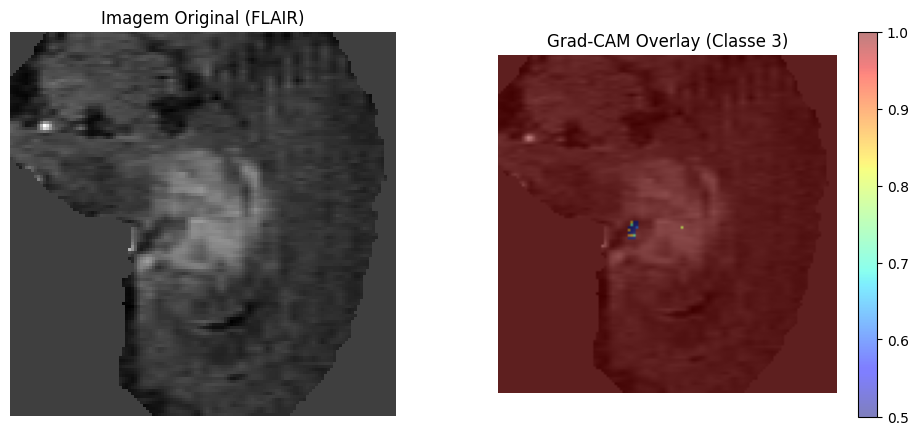

In [7]:
# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Imagem Original (FLAIR)")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay (Classe 3)")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, vmin=0.5, vmax=1.0)
plt.colorbar()
plt.axis("off")

plt.show()

In [8]:
reset_gpu_context(['model_unet', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: model_unet
Deletando variável: cam
Deletando variável: result
Deletando variável: heatmap_norm
VRAM Alocada: 148.92MB
VRAM Reservada: 216.00MB
--- Ambiente pronto para nova amostragem ---


#### 2.1.2 SegResNet

In [9]:
model_segresnet = SegResNet(
  in_channels=4,
  out_channels=4,
  init_filters=16,
  dropout_prob=0.2,
).to(device)

model_segresnet.load_state_dict(torch.load("../models/best_metric_model_segresnet.pth"))
model_segresnet.eval()

print(model_segresnet)

SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, a

In [10]:
# O SegResNet tem camadas com ReLU inplace, o que pode causar problemas de gradiente durante o Grad-CAM.
for m in model_segresnet.modules():
  if hasattr(m, 'inplace'):
    m.inplace = False

# Pegando penultima camada
target_layer_segresnet = "up_layers.2.0.conv2.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_segresnet, target_layers=[target_layer_segresnet])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

>> Heatmap gerado com sucesso. Shape: (128, 128)


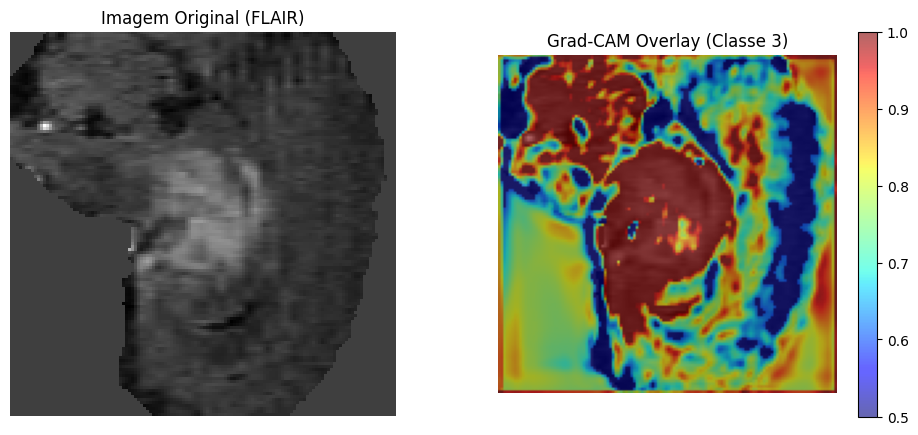

In [11]:
# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Imagem Original (FLAIR)")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay (Classe 3)")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.6, vmin=0.5, vmax=1.0)
plt.colorbar()
plt.axis("off")

plt.show()

In [12]:
reset_gpu_context(['model_segresnet', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: model_segresnet
Deletando variável: cam
Deletando variável: result
Deletando variável: heatmap_norm
VRAM Alocada: 332.23MB
VRAM Reservada: 532.00MB
--- Ambiente pronto para nova amostragem ---


#### 2.1.3 Swin UNETR

In [5]:
model_swin = SwinUNETR(
  in_channels=4,
  out_channels=4,
  feature_size=12,
  use_checkpoint=True,
).to(device)

model_swin.load_state_dict(torch.load("../models/best_metric_model_swin_unetr.pth"))
model_swin.eval()

print(model_swin)

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(4, 12, kernel_size=(2, 2, 2), stride=(2, 2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((12,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=12, out_features=36, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=12, out_features=12, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((12,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=12, out_features=48, bias=True)
              (linear2): Linear(in_features=

In [6]:
# Pegando penultima camada
target_layer_swin = "out.conv.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_swin, target_layers=[target_layer_swin])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.32 GiB. GPU 0 has a total capacity of 3.63 GiB of which 175.12 MiB is free. Including non-PyTorch memory, this process has 3.40 GiB memory in use. Of the allocated memory 1.98 GiB is allocated by PyTorch, and 1.33 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Imagem Original (FLAIR)")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay (Classe 3)")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, vmin=0.5, vmax=1.0)
plt.colorbar()
plt.axis("off")

plt.show()

In [16]:
reset_gpu_context(['model_swin', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: model_swin
Deletando variável: cam
VRAM Alocada: 365.23MB
VRAM Reservada: 534.00MB
--- Ambiente pronto para nova amostragem ---


### 2.2 SHAP

In [17]:
# Para volumes 3D, o GradientExplainer é o mais indicado para PyTorch
background = torch.zeros_like(input_tensor).to(device)

In [18]:
class SegmentationModelWrapper(torch.nn.Module):
  def __init__(self, model, class_idx):
    super().__init__()
    self.model = model
    self.class_idx = class_idx

  def forward(self, x):
    logits = self.model(x)
    # Seleciona a classe desejada e soma todos os voxels
    # para criar um "Score Total" (Escalar)
    return logits[:, self.class_idx].sum(dim=(1, 2, 3)).unsqueeze(1)

#### 2.2.1 U-Net 3D

In [ ]:
model_unet = UNet(
  spatial_dims=3,
  in_channels=4,
  out_channels=4,
  channels=(16, 32, 64, 128, 256),
  strides=(2, 2, 2, 2),
  num_res_units=2,
).to(device)

model_unet.load_state_dict(torch.load("../models/best_metric_model_Unet_3D.pth"))
model_unet.eval()

In [ ]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_unet, class_idx=3).to(device)

explainer_unet = shap.GradientExplainer(wrapped_model, background)

shap_values_unet = explainer_unet.shap_values(input_tensor, nsamples=50)

In [ ]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_unet[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.abs(s).max() + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
# shap_values_unet[0] tem shape (1, 4, 128, 128, 128)
shap_to_plot = shap_values_unet[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades)

In [ ]:
reset_gpu_context(['model_unet', 'explainer_unet', 'shap_values_unet'])

#### 2.2.2 SegResNet

In [ ]:
model_segresnet = SegResNet(
  in_channels=4,
  out_channels=4,
  init_filters=16,
  dropout_prob=0.2,
).to(device)

model_segresnet.load_state_dict(torch.load("../models/best_metric_model_segresnet.pth"))
model_segresnet.eval()

In [ ]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_segresnet, class_idx=3).to(device)

explainer_seg = shap.GradientExplainer(wrapped_model, background)

shap_values_seg = explainer_seg.shap_values(input_tensor, nsamples=50)

In [ ]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_seg[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.abs(s).max() + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
shap_to_plot = shap_values_seg[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades)

In [ ]:
reset_gpu_context(['model_segresnet', 'explainer_seg', 'shap_values_seg'])

#### 2.2.3 Swin UNETR

In [ ]:
model_swin = SwinUNETR(
  in_channels=4,
  out_channels=4,
  feature_size=12,
  use_checkpoint=True,
).to(device)

model_swin.load_state_dict(torch.load("../models/best_metric_model_swin_unetr.pth"))
model_swin.eval()

In [ ]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_swin, class_idx=3).to(device)

explainer_swin = shap.GradientExplainer(wrapped_model, background)

shap_values_swin = explainer_swin.shap_values(input_tensor, nsamples=50)

In [ ]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_swin[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.abs(s).max() + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
shap_to_plot = shap_values_swin[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades)

In [ ]:
reset_gpu_context(['model_swin', 'explainer_swin', 'shap_values_swin'])